In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import gymnasium as gym
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import rl_utils

First, define the policy net

In [2]:
class PolicyNet(torch.nn.Module):
    def __init__(self,state_dim,hidden_dim,action_dim):
        super(PolicyNet,self).__init__()
        self.fc1 = torch.nn.Linear(state_dim,hidden_dim)
        self.fc2 = torch.nn.Linear(hidden_dim,action_dim)

    def forward(self,x):
        x = F.relu(self.fc1(x))
        return F.softmax(self.fc2(x),dim=1)

Define REINFORCE algorithm

In [ ]:
class REINFORCE:
    def __init__(self,state_dim,hidden_dim,action_dim,lr,gamma,device):
        self.policy_net = PolicyNet(state_dim,hidden_dim,action_dim).to(device)
        self.optimizer = torch.optim.Adam(self.policy_net.parameters(),
                                          lr=lr)
        self.gamma = gamma
        self.device = device

    def take_action(self,state):
        state = torch.tensor(np.array(state),dtype=torch.float32).unsqueeze(0).to(self.device)
        probs = self.policy_net(state)
        action_dist = torch.distributions.Categorical(probs)
        action = action_dist.sample()
        return action.item()
    
    def update(self, transition_dict):
        reward_list = transition_dict['rewards']
        state_list = transition_dict['states']
        action_list = transition_dict['actions']

        G = 0
        returns = []
        for r in reversed(reward_list):
            G = r + self.gamma * G
            returns.insert(0, G)
        
        # convert to tensor and do normalization
        returns = torch.tensor(returns, dtype=torch.float32).to(self.device)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8) 

        # do backward only once
        states = torch.tensor(np.array(state_list), dtype=torch.float32).to(self.device)
        actions = torch.tensor(action_list).view(-1, 1).to(self.device)
        
        probs = self.policy_net(states)        
        # avoid underflow
        action_dist = torch.distributions.Categorical(probs)
        log_probs = action_dist.log_prob(actions.squeeze())

        loss = torch.sum(-log_probs.view(-1) * returns)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()


Try the algorithm in the env

In [ ]:
learning_rate = 1e-3
num_episodes = 1000
hidden_dim = 128
gamma = 0.98
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else :
    device = 'cpu'

env_name = "CartPole-v1"
env = gym.make(env_name)
torch.manual_seed(0)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = REINFORCE(state_dim, hidden_dim, action_dim, learning_rate, gamma,
                  device)

return_list = []
for i in range(10):
    with tqdm(total=int(num_episodes / 10), desc='Iteration %d' % i) as pbar:
        for i_episode in range(int(num_episodes / 10)):
            episode_return = 0
            transition_dict = {
                'states': [],
                'actions': [],
                'next_states': [],
                'rewards': [],
                'dones': []
            }
            state,info = env.reset()
            done = False
            while not done:
                action = agent.take_action(state)
                next_state, reward, terminated, truncated,info = env.step(action)
                transition_dict['states'].append(state)
                transition_dict['actions'].append(action)
                transition_dict['next_states'].append(next_state)
                transition_dict['rewards'].append(reward)
                done = terminated or truncated
                transition_dict['dones'].append(done)
                state = next_state
                episode_return += reward
            return_list.append(episode_return)
            agent.update(transition_dict)
            if (i_episode + 1) % 10 == 0:
                pbar.set_postfix({
                    'episode':
                    '%d' % (num_episodes / 10 * i + i_episode + 1),
                    'return':
                    '%.3f' % np.mean(return_list[-10:])
                })
            pbar.update(1)

Iteration 9: 100%|██████████| 100/100 [00:02<00:00, 37.68it/s, episode=1000, return=483.400]


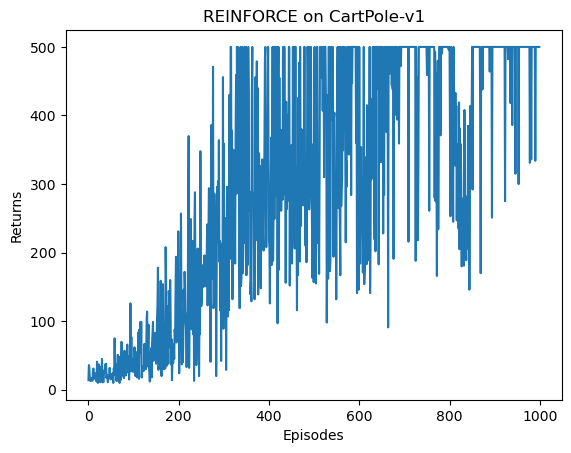

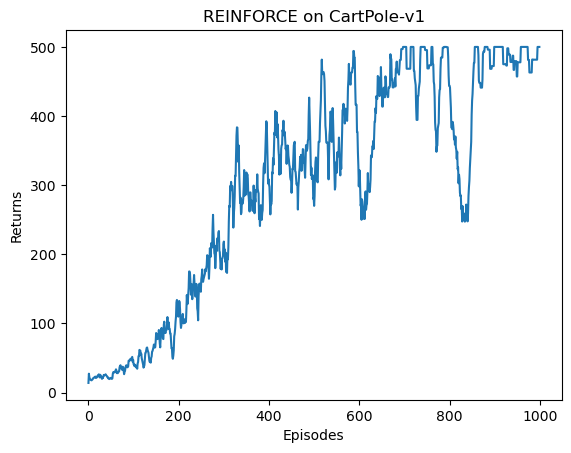

In [5]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('REINFORCE on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('REINFORCE on {}'.format(env_name))
plt.show()

Return drop shows that the algorithm reached the solution, but not convergence stablely. This is caused by MC method, some bad exploration will cause huge punishment, damage the policy. one solution to this problem is introduce a moving average baseline